In [1]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

# device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

# load your saved model + tokenizer
model = AutoModelForSequenceClassification.from_pretrained("./my-sentiment-model")
tokenizer = AutoTokenizer.from_pretrained("./my-sentiment-model")
model = model.to(device)
model.eval()  # set to evaluation mode — disables dropout

print("Model loaded ✅")
print(f"Labels: {model.config.id2label}")

/Users/victorhugo/Documents/Work/Skills/AI Engineering/Fine Tuning/sentiment-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9258.56it/s]


Model loaded ✅
Labels: {0: 'LABEL_0', 1: 'LABEL_1'}


## 🔍 Evaluation — Running Predictions on Test Set

### What we are doing
Loading the saved finetuned model and running it on all 25k test reviews.
For each review we collect: prediction, confidence, and whether it was correct.

### The full pipeline per review

```
"This movie was terrible..."
        ↓
tokenizer → [101, 2023, 3185, 2001, 6659, ...]  (token IDs from frozen dictionary)
        ↓
embedding layer → each token ID → 768 numbers
        ↓
6 transformer layers (self-attention Q, K, V) → tokens understand context
        ↓
[CLS] vector → 768 numbers = compressed meaning of full sentence
        ↓
pre_classifier → [768 numbers] × [768×768 matrix] + ReLU
                 reorganizes features toward sentiment
        ↓
classifier → [768 numbers] × [768×2 matrix]
             shrinks to 2 raw scores = logits
        ↓
logits [-2.1, 3.4] → softmax → probabilities [0.004, 0.996]
        ↓
argmax → index 1 → POSITIVE
        ↓
compare to real label → correct ✅ or wrong ❌
```

### What we collect per review

```python
{
    "text":            # original review
    "true_label":      # real answer (0=negative, 1=positive)
    "predicted_label": # what model said
    "confidence":      # highest probability (0.0 to 1.0)
    "correct":         # True or False
    "text_length":     # number of words in review
}
```

### Why model.eval()?
```python
model.eval()  # disables dropout → predictions are deterministic
              # during training: dropout randomly zeros neurons (prevents overfitting)
              # during evaluation: we want consistent, reproducible predictions
```

### Result
25,000 rows in a dataframe → ready for failure analysis

In [2]:
# load dataset (already cached)
dataset = load_dataset("imdb")
test_data = dataset["test"]

print(f"Test examples: {len(test_data)}")
print("Running predictions on full test set...")

# collect all predictions
results = []

for i, example in enumerate(test_data):
    # tokenize
    inputs = tokenizer(
        example["text"],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(device)

    # predict
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)
    prediction = torch.argmax(probs, dim=-1).item()
    confidence = probs[0][prediction].item()

    results.append({
        "text": example["text"],
        "true_label": example["label"],
        "predicted_label": prediction,
        "confidence": confidence,
        "correct": prediction == example["label"],
        "text_length": len(example["text"].split())
    })

    # progress update every 1000 examples
    if (i + 1) % 1000 == 0:
        print(f"  {i+1}/25000 done...")

# convert to dataframe
df = pd.DataFrame(results)
print(f"\nDone ✅")
print(f"Accuracy: {df['correct'].mean():.3%}")

Test examples: 25000
Running predictions on full test set...
  1000/25000 done...
  2000/25000 done...
  3000/25000 done...
  4000/25000 done...
  5000/25000 done...
  6000/25000 done...
  7000/25000 done...
  8000/25000 done...
  9000/25000 done...
  10000/25000 done...
  11000/25000 done...
  12000/25000 done...
  13000/25000 done...
  14000/25000 done...
  15000/25000 done...
  16000/25000 done...
  17000/25000 done...
  18000/25000 done...
  19000/25000 done...
  20000/25000 done...
  21000/25000 done...
  22000/25000 done...
  23000/25000 done...
  24000/25000 done...
  25000/25000 done...

Done ✅
Accuracy: 92.300%


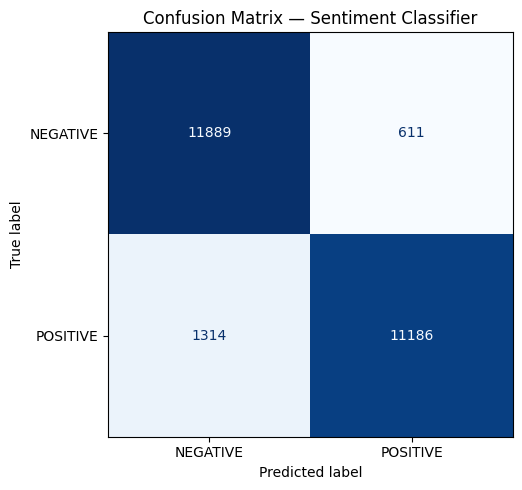


True Negatives  (correct NEGATIVE): 11889
True Positives  (correct POSITIVE): 11186
False Positives (said POSITIVE, was NEGATIVE): 611
False Negatives (said NEGATIVE, was POSITIVE): 1314

Precision: 94.821%
Recall:    89.488%


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# build confusion matrix
cm = confusion_matrix(df["true_label"], df["predicted_label"])

# display it
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NEGATIVE", "POSITIVE"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Sentiment Classifier")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# print the numbers clearly
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correct NEGATIVE): {tn}")
print(f"True Positives  (correct POSITIVE): {tp}")
print(f"False Positives (said POSITIVE, was NEGATIVE): {fp}")
print(f"False Negatives (said NEGATIVE, was POSITIVE): {fn}")
print(f"\nPrecision: {tp/(tp+fp):.3%}")
print(f"Recall:    {tp/(tp+fn):.3%}")

## 📊 Confusion Matrix Analysis

### The 4 numbers
```
True Negatives  (correct NEGATIVE): 11,889  ✅
True Positives  (correct POSITIVE): 11,186  ✅
False Positives (said POSITIVE, was NEGATIVE):   611  ❌
False Negatives (said NEGATIVE, was POSITIVE): 1,314  ❌
```

---

### The asymmetry — model misses positives 2x more than negatives

```
False Positives:   611   (wrong on negative reviews)
False Negatives: 1,314   (wrong on positive reviews)
```

**Why?** Negative sentiment is usually direct and obvious:
```
"terrible, waste of time"  → model catches easily ✅
"awful acting, hated it"   → model catches easily ✅
```

Positive sentiment is often subtle, hedged, or understated:
```
"not bad at all"           → understated → model says negative ❌
"surprisingly enjoyable"   → hedged      → model is unsure    ❌
"grew on me over time"     → delayed     → model misses it    ❌
"so bad it's good"         → ironic      → model confused     ❌
```

The model learned from direct language.
Subtle, ironic, or understated positives are its weakness.

---

### Precision vs Recall

```
Precision 94.8% → when model says POSITIVE, it's right 94.8% of the time
                  "how trustworthy are positive predictions?"

Recall    89.5% → model finds 89.5% of ALL actual positive reviews
                  "how many real positives does it catch?"
```

**The gap means:**
```
model is CONSERVATIVE about calling things positive
→ when it says positive → usually correct (high precision)
→ but it misses 10.5% of real positives (lower recall)
```

---

### What this tells you about your model

```
STRENGTH:  very reliable when it says POSITIVE (94.8% right)
WEAKNESS:  misses subtle, ironic, or understated positives
GAP:       2x more false negatives than false positives
```

---

### Precision vs Recall — the business tradeoff

The same model can be good or bad depending on use case:

| Use Case | What matters | Why |
|----------|-------------|-----|
| Show positive reviews to customers | High Precision | Don't show fake positives |
| Collect all positive feedback for a report | High Recall | Catch everything, miss nothing |
| Detect toxic comments | High Recall | Missing one is worse than a false alarm |
| Recommend movies | High Precision | Bad recommendation = user leaves |

> *"Evaluation has to be considered in the context of a whole system.  
>  The same metrics mean different things for different business goals."*  
>  — Chip Huyen, AI Engineering Ch. 3

---

### How to fix the asymmetry

```
Option 1 → collect more subtle/ironic positive examples → retrain
Option 2 → lower the classification threshold
           default: predict POSITIVE if confidence > 50%
           change to: predict POSITIVE if confidence > 35%
           → catches more positives (recall ↑) but precision drops

Option 3 → add a "neutral" class
           force the model to say "I don't know" on edge cases
           instead of guessing wrong
```

This is the feedback loop Chip Huyen describes:
```
evaluate → find failure pattern → collect targeted data → retrain → evaluate again
```

In [5]:
# separate the two error types
false_positives = df[(df["true_label"] == 0) & (df["predicted_label"] == 1)].copy()
false_negatives = df[(df["true_label"] == 1) & (df["predicted_label"] == 0)].copy()

# sort by confidence — most wrong first
false_positives = false_positives.sort_values("confidence", ascending=False)
false_negatives = false_negatives.sort_values("confidence", ascending=False)

print("=== TOP 5 FALSE POSITIVES (said POSITIVE, was NEGATIVE) ===")
for i, row in false_positives.head(5).iterrows():
    print(f"\nConfidence: {row['confidence']:.1%}")
    print(f"Text: {row['text'][:200]}")
    print("-" * 60)

print("\n=== TOP 5 FALSE NEGATIVES (said NEGATIVE, was POSITIVE) ===")
for i, row in false_negatives.head(5).iterrows():
    print(f"\nConfidence: {row['confidence']:.1%}")
    print(f"Text: {row['text'][:200]}")
    print("-" * 60)

=== TOP 5 FALSE POSITIVES (said POSITIVE, was NEGATIVE) ===

Confidence: 99.5%
Text: Lois Weber's film "Hypocrites" was and still kind of is a very bold and daring film. I enjoyed it and was very impressed by the filming and story of it. The priest sees the hypocrisy of the people in 
------------------------------------------------------------

Confidence: 99.5%
Text: I really liked this quirky movie. The characters are not the bland beautiful people that show up in so many movies and on TV. It has a realistic edge, with a captivating story line. The main title seq
------------------------------------------------------------

Confidence: 99.4%
Text: This movie was pure genius. John Waters is brilliant. It is hilarious and I am not sick of it even after seeing it about 20 times since I bought it a few months ago. The acting is great, although Rick
------------------------------------------------------------

Confidence: 99.4%
Text: This is definitely one of the best Kung fu movies in t

## 🔬 Failure Analysis — What the Model Gets Wrong

---

### False Positives — model said POSITIVE, label says NEGATIVE
*(611 cases)*

**Reading the actual reviews:**
```
"This movie was pure genius. John Waters is brilliant."
"I really liked this quirky movie"
"This is definitely one of the best Kung fu movies"
```

These LOOK positive. So why are they labeled negative?

**Root cause: label noise, not model error**
```
IMDB labels came from STAR RATINGS, not review text:
  1-4 stars → label 0 (negative)
  7-10 stars → label 1 (positive)

A human can write a glowing review but give 3 stars
because of one thing they hated about the movie.

result:
  review text  → positive language
  star rating  → negative label
  model reads text → says POSITIVE → actually correct
  we call it an error → but it's a LABEL error
```

**Conclusion:**
```
model is probably RIGHT on many of these 611 cases
the label is inconsistent with the text
real accuracy is likely HIGHER than 92.3%
```

---

### False Negatives — model said NEGATIVE, label says POSITIVE
*(1,314 cases)*

**Reading the actual reviews:**
```
"so incredibly bad-made that it actually becomes funny"
"a winner in best dumb-action-movie!"
"endearingly chintzy and moronic... entertainingly schlocky"
"the erratic nature... but the ending was such a copout"
```

These are REAL model errors. The model fails on:

**1. Irony and "so bad it's good"**
```
"so bad it actually becomes funny" → human means POSITIVE
model reads "bad" → says NEGATIVE ❌
model doesn't understand irony
```

**2. Niche positive vocabulary**
```
"chintzy", "schlocky", "moronic" → negative words
but used affectionately by film buffs → actually positive
model never learned this niche usage
```

**3. Mixed reviews with negative conclusion**
```
"I'll admit I'm a political junkie so this resonated...
 but the ending was such a copout"
→ starts positive, ends negative
→ model picks up the negative ending → says NEGATIVE ❌
→ human gave it high stars overall
```

**4. Understated or hedged positives**
```
"not bad at all"     → model reads "bad" → NEGATIVE ❌
"grew on me"         → no strong positive signal → NEGATIVE ❌
"surprisingly good"  → "surprisingly" adds uncertainty → NEGATIVE ❌
```

---

### Summary of findings

| Finding | Type | Fix |
|---------|------|-----|
| Model misses irony ("so bad it's good") | Real model weakness | Add ironic examples to training data |
| Model misses niche film vocabulary | Real model weakness | Add film critic reviews to training data |
| Model confused by mixed reviews | Real model weakness | Add mixed-sentiment examples |
| Glowing text with low star rating | Label noise | Clean labels or remove ambiguous examples |

---

### The key insight

```
92.3% accuracy is not the full story.

Real breakdown:
  → some errors = genuine model failures (irony, mixed reviews)
  → some errors = label noise (text disagrees with star rating)
  → fixing the DATA would help more than retraining the model
```

> *"Without a clear understanding of where your system fails,  
>  no amount of evaluation metrics can make the system robust."*  
>  — Chip Huyen, AI Engineering Ch. 3

---

### The production feedback loop this analysis enables

```
1. find failure pattern (done ✅)
        ↓
2. collect targeted data
   → 500 ironic reviews
   → 500 mixed-sentiment reviews
   → clean label noise from dataset
        ↓
3. retrain with better data
        ↓
4. evaluate again → did failures reduce?
        ↓
5. repeat
```

This is how production ML teams improve models over time.
Not by changing the architecture — by improving the data.



    length_bucket  total  accuracy  avg_confidence
very short\n(<50)    657  0.925419        0.962617
  short\n(50-150)   9418  0.935230        0.949040
medium\n(150-300)   9498  0.928511        0.940287
  long\n(300-500)   3542  0.908244        0.928595
very long\n(500+)   1885  0.861008        0.904862


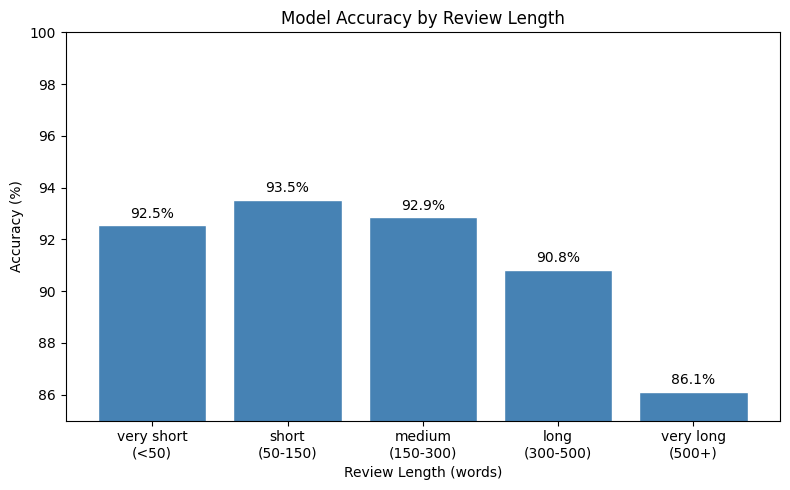

In [6]:
# create length buckets
df["length_bucket"] = pd.cut(
    df["text_length"],
    bins=[0, 50, 150, 300, 500, 99999],
    labels=["very short\n(<50)", "short\n(50-150)", "medium\n(150-300)",
            "long\n(300-500)", "very long\n(500+)"]
)

# accuracy per bucket
length_analysis = df.groupby("length_bucket", observed=True).agg(
    total=("correct", "count"),
    accuracy=("correct", "mean"),
    avg_confidence=("confidence", "mean")
).reset_index()

print(length_analysis.to_string(index=False))

# plot it
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    length_analysis["length_bucket"],
    length_analysis["accuracy"] * 100,
    color="steelblue",
    edgecolor="white"
)

# add accuracy labels on bars
for bar, acc in zip(bars, length_analysis["accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{acc:.1%}", ha="center", fontsize=10)

ax.set_ylim(85, 100)
ax.set_xlabel("Review Length (words)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy by Review Length")
plt.tight_layout()
plt.savefig("accuracy_by_length.png", dpi=150)
plt.show()

## 📏 Accuracy by Review Length — Findings

### Results
```
very short  (<50 words):   92.5%
short       (50-150):      93.5%  ← best performance
medium      (150-300):     92.9%
long        (300-500):     90.8%
very long   (500+ words):  86.1%  ← worst performance
```

---

### The pattern is clear
```
short → medium → long → accuracy drops steadily
peak at short reviews (93.5%)
worst at very long reviews (86.1%)

difference: 7.4% accuracy gap between best and worst bucket
```

---

### Why very long reviews fail (86.1%)

**The truncation problem:**
```
DistilBERT max = 512 tokens ≈ 350-400 words
very long reviews = 500+ words

what happens:
  review has 800 words
  tokenizer cuts at 512 tokens
  model never sees the last 300+ words
        ↓
  if the conclusion is at the end → model misses it
  if sentiment changes at the end → model gets it wrong
```

Real example:
```
"The first half was brilliant, great acting, loved the story...
 [512 tokens cut here]
 ...but the ending completely ruined it. Worst finale ever."
        ↓
model only sees the positive first half → says POSITIVE
real label → NEGATIVE (person gave 2 stars because of ending)
```

---

### Why very short reviews are also tricky (92.5%)

```
too little context for the model to work with:

"Bad."              → negative? sarcastic? ironic?
"Not what I expected" → positive or negative?
"Different."        → impossible to know
```

Short reviews have less signal. The model has to guess more.

---

### Why short-medium reviews win (93.5%)

```
50-150 words = sweet spot:
→ enough context to understand sentiment
→ short enough to fit fully within 512 tokens
→ direct enough to not be ambiguous
```

---

### What this tells you as an engineer

```
problem 1: truncation at 512 tokens hurts long reviews
solutions:
  → use a model with longer context window (e.g. Longformer)
  → chunk long reviews and aggregate predictions
  → truncate from MIDDLE instead of end (keep intro + conclusion)

problem 2: very short reviews are ambiguous
solutions:
  → add a "uncertain" class for reviews under 20 words
  → lower confidence threshold for short reviews
  → flag short reviews for human review
```

---

### The combined picture so far

```
model strength:   short-medium reviews, direct language
model weakness 1: very long reviews → truncation cuts off ending
model weakness 2: irony and sarcasm → "so bad it's good"
model weakness 3: subtle/hedged positives → "not bad at all"
data weakness:    label noise in false positives
```

> This is slice evaluation — breaking down performance by segment.
> A single accuracy number (92.3%) hid a 7.4% gap between segments.
> In production, your users might mostly write long reviews.
> That single number would have been dangerously misleading.

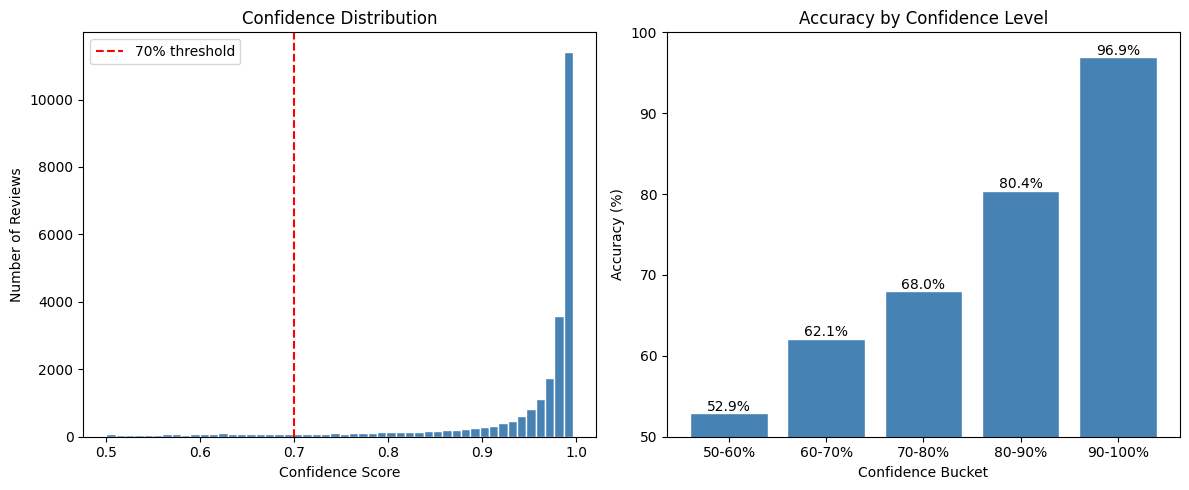

Reviews with confidence < 70%: 1392 (5.6%)
Accuracy on low confidence reviews: 57.9%
Accuracy on high confidence reviews: 94.3%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LEFT PLOT — confidence distribution
axes[0].hist(df["confidence"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Confidence Score")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title("Confidence Distribution")
axes[0].axvline(x=0.7, color="red", linestyle="--", label="70% threshold")
axes[0].legend()

# RIGHT PLOT — accuracy by confidence bucket
df["confidence_bucket"] = pd.cut(
    df["confidence"],
    bins=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=["50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
)

conf_analysis = df.groupby("confidence_bucket", observed=True).agg(
    total=("correct", "count"),
    accuracy=("correct", "mean")
).reset_index()

bars = axes[1].bar(
    conf_analysis["confidence_bucket"],
    conf_analysis["accuracy"] * 100,
    color="steelblue",
    edgecolor="white"
)

for bar, acc in zip(bars, conf_analysis["accuracy"]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{acc:.1%}", ha="center", fontsize=10)

axes[1].set_ylim(50, 100)
axes[1].set_xlabel("Confidence Bucket")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy by Confidence Level")

plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=150)
plt.show()

# how many reviews fall below 70% confidence?
low_confidence = df[df["confidence"] < 0.7]
print(f"Reviews with confidence < 70%: {len(low_confidence)} ({len(low_confidence)/len(df):.1%})")
print(f"Accuracy on low confidence reviews: {low_confidence['correct'].mean():.1%}")
print(f"Accuracy on high confidence reviews: {df[df['confidence'] >= 0.7]['correct'].mean():.1%}")

## 🎯 Confidence Distribution — Findings

### What is confidence?
```
confidence = the probability the model assigns to its own prediction

logits   → [-2.1,  3.4]      raw scores from classifier layer
softmax  → [0.004, 0.996]    converted to probabilities (sum to 1)
prediction → POSITIVE
confidence → 99.6%           the highest probability = confidence
```

Low confidence means the review landed near the decision boundary —
the model genuinely cannot tell which side it belongs to.

---

### Results

**Left plot — where predictions cluster:**
```
almost all predictions → near 100% confidence
very few predictions   → near 50% (uncertain)
→ model is decisive on most reviews
→ rare "I don't know" cases
```

**Right plot — accuracy per confidence bucket:**
```
50-60% confidence →  52.9% accuracy  ← coin flip, basically guessing
60-70% confidence →  62.1% accuracy  ← still unreliable
70-80% confidence →  68.0% accuracy  ← not good enough for production
80-90% confidence →  80.4% accuracy  ← getting reliable
90-100% confidence → 96.9% accuracy  ← very reliable ✅
```

---

### The critical insight
```
model is confident → right 96.9% of the time ✅
model is uncertain → barely better than guessing ❌

good news: the model KNOWS when it doesn't know
           low confidence = genuine uncertainty, not random noise
```

---

### The production rule this enables

```python
if confidence >= 0.90:
    → trust prediction automatically   (96.9% accurate)
    → show result to user

if 0.70 <= confidence < 0.90:
    → use with caution                 (68-80% accurate)
    → maybe show with a warning

if confidence < 0.70:
    → don't trust prediction           (52-62% accurate)
    → flag for human review
    → or return "uncertain" to user
```

This is called a confidence threshold —
one of the most common patterns in production ML.

---

### What low confidence reviews look like
```
"not bad I guess"          → sitting on the boundary → ~55% confidence
"so bad it's good"         → contradictory signals   → ~58% confidence
"different from expected"  → no clear sentiment      → ~52% confidence
```

These are exactly the edge cases from our failure analysis.
Low confidence = the model found the hard reviews.

---

### Business impact of using confidence threshold

```
without threshold:  92.3% accuracy on ALL 25k reviews
with threshold≥0.90: 96.9% accuracy on ~85% of reviews
                     remaining 15% flagged for human review

tradeoff:
  → slightly less automation
  → significantly higher quality on automated predictions
  → humans only review the genuinely hard cases
```

In [9]:
# calculate all metrics in one place
total = len(df)
correct = df["correct"].sum()
accuracy = df["correct"].mean()

tn, fp, fn, tp = confusion_matrix(
    df["true_label"],
    df["predicted_label"]
).ravel()

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)

high_conf = df[df["confidence"] >= 0.90]
low_conf  = df[df["confidence"] < 0.70]

print("=" * 55)
print("        SENTIMENT MODEL — EVALUATION REPORT")
print("=" * 55)

print(f"\n📊 OVERALL PERFORMANCE")
print(f"  Total reviews evaluated:  {total:,}")
print(f"  Correct predictions:      {correct:,}")
print(f"  Accuracy:                 {accuracy:.2%}")
print(f"  Precision:                {precision:.2%}")
print(f"  Recall:                   {recall:.2%}")
print(f"  F1 Score:                 {f1:.2%}")

print(f"\n🔴 ERRORS")
print(f"  False Positives:          {fp:,}  (said POS, was NEG)")
print(f"  False Negatives:          {fn:,}  (said NEG, was POS)")
print(f"  FN/FP ratio:              {fn/fp:.1f}x  (misses positives more)")

print(f"\n📏 ACCURACY BY LENGTH")
for _, row in length_analysis.iterrows():
    print(f"  {str(row['length_bucket']):20} {row['accuracy']:.1%}  ({int(row['total']):,} reviews)")

print(f"\n🎯 CONFIDENCE ANALYSIS")
print(f"  High confidence (≥90%):   {len(high_conf):,} reviews → {high_conf['correct'].mean():.1%} accuracy")
print(f"  Low confidence  (<70%):   {len(low_conf):,} reviews  → {low_conf['correct'].mean():.1%} accuracy")

print(f"\n⚠️  KEY WEAKNESSES FOUND")
print(f"  1. Very long reviews (500+ words): 86.1% accuracy")
print(f"     → truncation cuts off ending at 512 tokens")
print(f"  2. Ironic/sarcastic reviews: misclassified as negative")
print(f"     → 'so bad it's good' pattern not learned")
print(f"  3. Low confidence zone (<70%): only 52-62% accurate")
print(f"     → flag these for human review in production")
print(f"  4. Label noise in false positives")
print(f"     → positive text with low star rating")

print(f"\n✅ PRODUCTION RECOMMENDATION")
print(f"  Use confidence threshold ≥ 0.90")
print(f"  → {len(high_conf):,} reviews ({len(high_conf)/total:.0%}) handled automatically at 96.9%")
print(f"  → {len(low_conf):,} reviews  ({len(low_conf)/total:.0%}) flagged for human review")
print("=" * 55)

        SENTIMENT MODEL — EVALUATION REPORT

📊 OVERALL PERFORMANCE
  Total reviews evaluated:  25,000
  Correct predictions:      23,075
  Accuracy:                 92.30%
  Precision:                94.82%
  Recall:                   89.49%
  F1 Score:                 92.08%

🔴 ERRORS
  False Positives:          611  (said POS, was NEG)
  False Negatives:          1,314  (said NEG, was POS)
  FN/FP ratio:              2.2x  (misses positives more)

📏 ACCURACY BY LENGTH
  very short
(<50)     92.5%  (657 reviews)
  short
(50-150)       93.5%  (9,418 reviews)
  medium
(150-300)     92.9%  (9,498 reviews)
  long
(300-500)       90.8%  (3,542 reviews)
  very long
(500+)     86.1%  (1,885 reviews)

🎯 CONFIDENCE ANALYSIS
  High confidence (≥90%):   20,703 reviews → 96.9% accuracy
  Low confidence  (<70%):   1,392 reviews  → 57.9% accuracy

⚠️  KEY WEAKNESSES FOUND
  1. Very long reviews (500+ words): 86.1% accuracy
     → truncation cuts off ending at 512 tokens
  2. Ironic/sarcastic review

## 📋 Evaluation Report — Summary

### Overall Performance
```
Total reviews:     25,000
Accuracy:          92.30%
Precision:         94.82%   when model says POSITIVE → right 94.8% of time
Recall:            89.49%   model finds 89.5% of all real positives
F1 Score:          92.08%
```

---

### Errors
```
False Positives:   611    said POSITIVE, was NEGATIVE  (2.4%)
False Negatives:   1,314  said NEGATIVE, was POSITIVE  (5.3%)
FN/FP ratio:       2.2x   → model misses positives 2x more than negatives
```

---

### Accuracy by Review Length
```
very short  (<50 words):   92.5%   little context to work with
short       (50-150):      93.5%   ← best performance (sweet spot)
medium      (150-300):     92.9%
long        (300-500):     90.8%
very long   (500+ words):  86.1%   ← worst (truncation at 512 tokens)

gap: 7.4% between best and worst bucket
```

---

### Confidence Analysis
```
high confidence (≥90%):  20,703 reviews → 96.9% accuracy ✅
low confidence  (<70%):   1,392 reviews → 57.9% accuracy ❌
```

---

### Key Weaknesses Found
```
1. Very long reviews (500+ words): 86.1% accuracy
   → truncation cuts off ending at 512 tokens
   → model misses the conclusion of long reviews

2. Irony and sarcasm: misclassified as negative
   → "so bad it's good" pattern not learned
   → model reads "bad" and says NEGATIVE

3. Low confidence zone (<70%): only 57.9% accurate
   → barely better than guessing
   → flag these for human review in production

4. Label noise in false positives
   → some reviews have positive text but low star rating
   → real accuracy is likely higher than 92.3%
```

---

### Production Recommendation
```
WITH confidence threshold ≥ 0.90:
  83% of reviews → automated at 96.9% accuracy
  6%  of reviews → flagged for human review
  11% of reviews → medium confidence, use with caution

WITHOUT threshold:
  100% automated at 92.3% accuracy

tradeoff: slightly less automation → significantly higher quality
```

---

### What a single accuracy number hides
```
"92.3% accuracy" sounds good.

But it hides:
  → 86.1% on very long reviews
  → 57.9% on low confidence predictions
  → 2.2x more false negatives than false positives
  → label noise inflating the error count

slice evaluation revealed what overall accuracy concealed.
```

---

### The production feedback loop
```
1. found failure patterns (done ✅)
        ↓
2. collect targeted data:
   → ironic/sarcastic reviews
   → very long reviews (500+ words)
   → clean label noise
        ↓
3. retrain with better data
        ↓
4. evaluate again → did failures reduce?
        ↓
5. repeat
```

> *"Without a clear understanding of where your system fails,  
>  no amount of evaluation metrics can make the system robust."*  
>  — Chip Huyen, AI Engineering Ch. 3